# Example 008: SPS kicker impedance data

This notebook inspects the frequency-domain impedance of the SPS kickers. The four components are Driving X/Y and Detuning X/Y.

The impedance file contains frequency in GHz followed by four complex-valued components.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import iddefix

%matplotlib inline

DATA_DIR = Path.cwd() / "examples" / "data"
if not DATA_DIR.exists():  # Also support running from examples/
    DATA_DIR = Path.cwd() / "data"

IMPEDANCE_FILE = DATA_DIR / "Z_kickers_postLS2_SPSmodel.dat"

## Load and plot the impedance

The impedance columns are ordered as Driving X, Driving Y, Detuning X, and Detuning Y. These are transverse impedance components, so the physical unit is Ω/m. The plots use MΩ/m for readability; fitting uses the unscaled values in Ω/m.

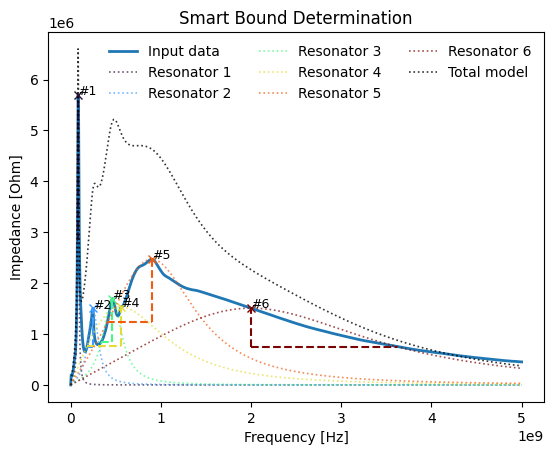

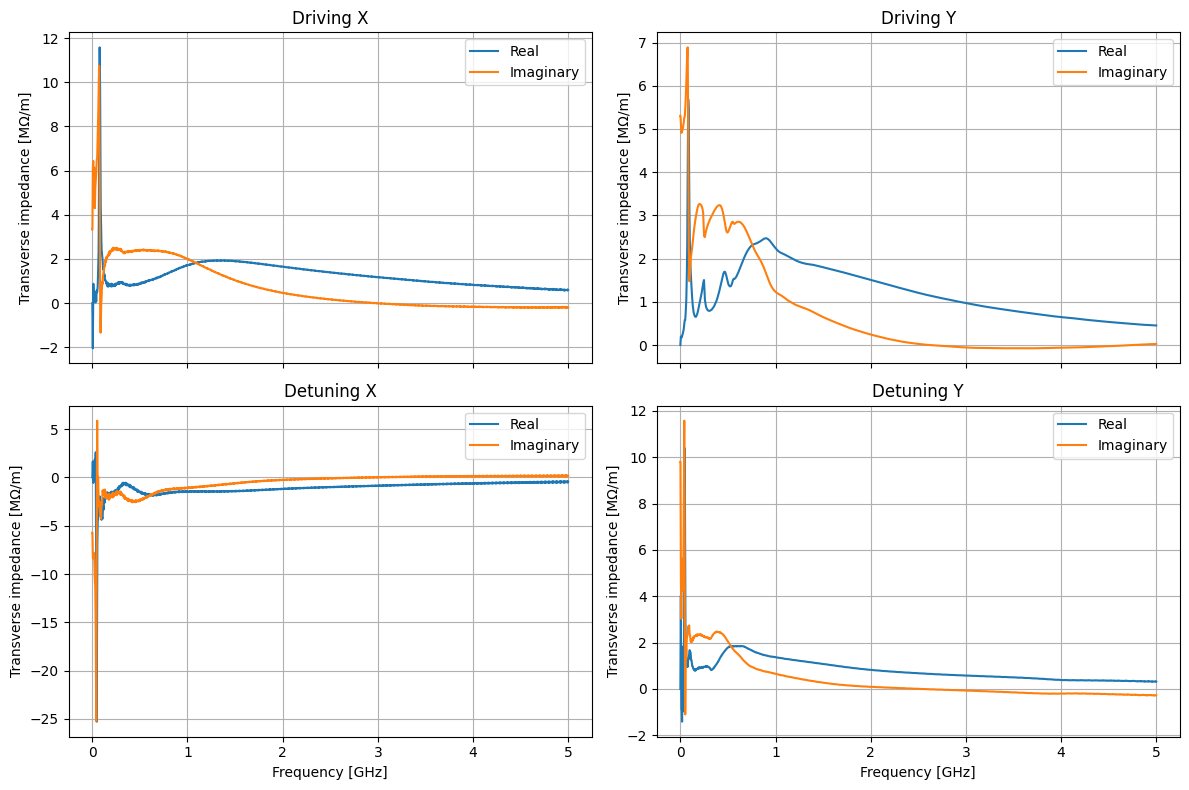

In [14]:
impedance_data = np.loadtxt(IMPEDANCE_FILE, dtype=str)
frequency_ghz = impedance_data[:, 0].astype(float)
impedance_components = np.char.replace(impedance_data[:, 1:], "i", "j").astype(complex)
component_names = ("Driving X", "Driving Y", "Detuning X", "Detuning Y")

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for index, (axis, name) in enumerate(zip(axes.flat, component_names)):
    component = impedance_components[:, index]
    axis.plot(frequency_ghz, component.real / 1e6, label="Real")
    axis.plot(frequency_ghz, component.imag / 1e6, label="Imaginary")
    axis.set_title(name)
    axis.set_ylabel("Transverse impedance [MΩ/m]")
    axis.grid(True)
    axis.legend()

for axis in axes[-1, :]:
    axis.set_xlabel("Frequency [GHz]")
fig.tight_layout()
plt.show()

## Fit resonators to Driving Y

Start with the Driving Y impedance. SmartBounds detects candidate modes from the real part and uses the transverse resonator shape to estimate their parameter bounds. Inspect the result and adjust the peak threshold or spacing if needed. CMA-ES then fits the real impedance.

In [15]:
%matplotlib ipympl
frequency = frequency_ghz * 1e9
driving_y_impedance = impedance_components[:, 1]
minimum_peak_height = 1e6  # 0.01 * np.max(np.abs(driving_y_impedance))

driving_y_bounds = iddefix.SmartBoundDetermination(
    frequency,
    np.real(driving_y_impedance),
    minimum_peak_height=1e6,
    impedance_type="real",
    plane="transverse",
    # interactive=True,
)
driving_y_bounds.add_peak(2e9)

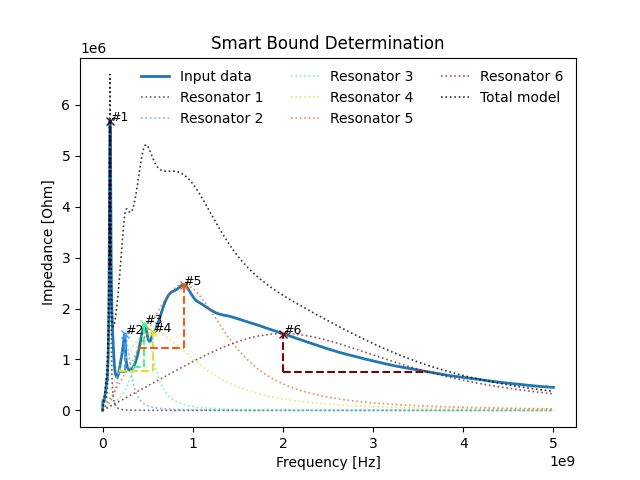


--------------------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |        fres [Hz]        
--------------------------------------------------------------------------------
    1     |567612.67 to 56761266.83|  2.47 to 24.70   |  7.41e+07 to 9.08e+07   
    2     |147635.66 to 14763565.64|   0.93 to 9.32   |  1.88e+08 to 3.26e+08   
    3     |166488.07 to 16648806.84|   0.95 to 9.50   |  3.53e+08 to 6.04e+08   
    4     |126637.29 to 12663728.58|   0.29 to 2.94   |  1.25e+08 to 1.55e+09   
    5     |226776.64 to 22677663.95|   0.43 to 4.35   |  4.56e+08 to 1.69e+09   
    6     |133757.32 to 13375732.41|   0.37 to 3.69   |  8.28e+08 to 4.31e+09   
--------------------------------------------------------------------------------


In [16]:
driving_y_bounds.inspect(show_bounds=False, show_components=True)
driving_y_bounds.to_table()

The automatic bounds are a starting point. Review the detected modes before running CMA-ES, especially if the spectrum contains broad structures or closely spaced peaks.

In [17]:
driving_y_model = iddefix.EvolutionaryAlgorithm(
    frequency,
    driving_y_impedance,
    N_resonators=driving_y_bounds.N_resonators,
    parameterBounds=driving_y_bounds.parameterBounds,
    parameterEstimates=driving_y_bounds.parameterEstimates,
    plane="transverse",
    objectiveFunction="complex",
)

driving_y_model.load_resonator_parameters("""
----------------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |       fres [Hz]        
----------------------------------------------------------------------------
    1     |   5.30e+06 ± 1.5e+04   |   3.60 ± 0.01    |   8.57e+07 ± 3.4e+04   
    2     |   8.17e+05 ± 9.6e+03   |   3.26 ± 0.07    |   2.34e+08 ± 4.0e+05   
    3     |   5.98e+05 ± 9.9e+03   |   6.80 ± 0.22    |   4.55e+08 ± 5.1e+05   
    4     |   1.32e+06 ± 2.0e+04   |   1.51 ± 0.02    |   8.69e+08 ± 1.7e+06   
    5     |   6.56e+05 ± 3.8e+04   |   1.02 ± 0.03    |   1.69e+09 ± 6.2e+06   
    6     |   5.87e+05 ± 1.6e+04   |   0.37 ± 0.01    |   4.31e+09 ± 8.4e+07   
----------------------------------------------------------------------------
""")

# driving_y_model.run_cmaes(
#     maxiter=3000,
#     popsize=60,
#     sigma=0.5,
# )

[!] Using the fully decayed resonator formalism for impedance


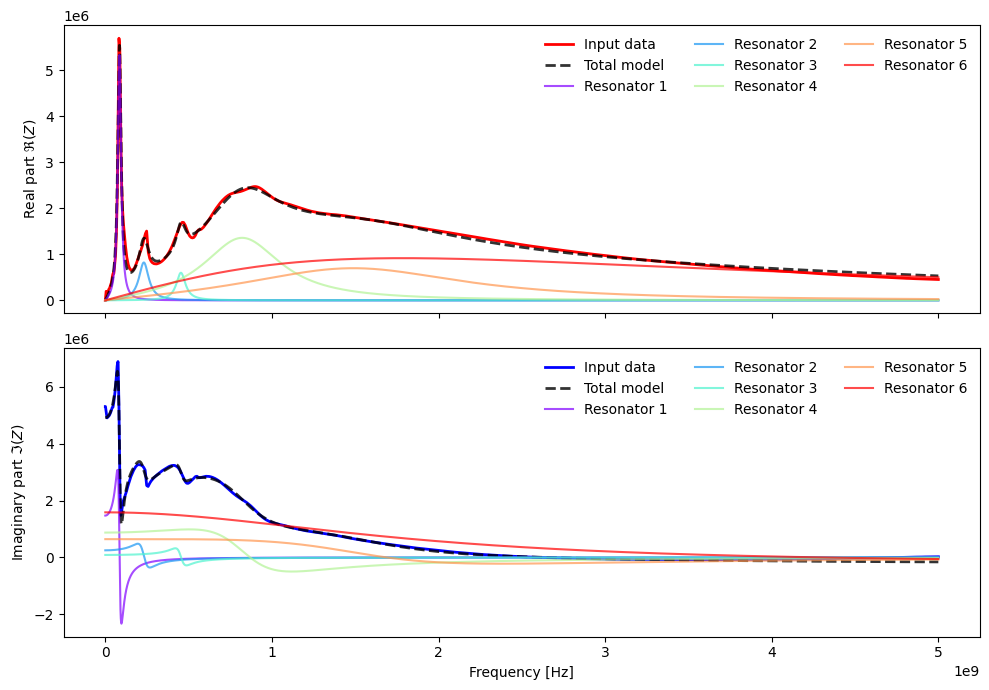

(<Figure size 1000x700 with 2 Axes>,
 array([<Axes: ylabel='Real part $\\Re(Z)$'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='Imaginary part $\\Im(Z)$'>],
       dtype=object))

In [21]:
driving_y_model.plot_model_components(cmap="rainbow")

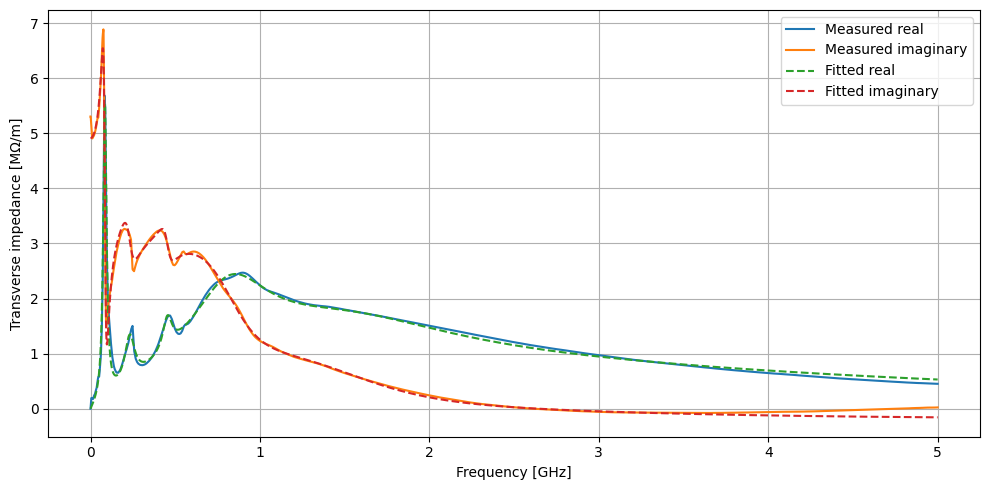

In [19]:
%matplotlib inline
plt.close("all")
fitted_driving_y_impedance = driving_y_model.get_impedance()

fig, axis = plt.subplots(figsize=(10, 5))
axis.plot(frequency_ghz, driving_y_impedance.real / 1e6, label="Measured real")
axis.plot(
    frequency_ghz,
    driving_y_impedance.imag / 1e6,
    label="Measured imaginary",
)
axis.plot(
    frequency_ghz,
    fitted_driving_y_impedance.real / 1e6,
    "--",
    label="Fitted real",
)
axis.plot(
    frequency_ghz,
    fitted_driving_y_impedance.imag / 1e6,
    "--",
    label="Fitted imaginary",
)
axis.set_xlabel("Frequency [GHz]")
axis.set_ylabel("Transverse impedance [MΩ/m]")
axis.grid(True)
axis.legend()
fig.tight_layout()
# plt.show()